# 03 — RAG Pipeline
**Prior Authorization Automation | Hannah-Hiltz GitHub Portfolio**

The purpose of this notebook is to build the Retrieval-Augmented Generation layer that grounds LLM outputs in real payer policy language.

**Without RAG:** LLM generates plausible but generic rationale.

**With RAG:** LLM cites specific payer criteria — which is what actually gets authorizations approved.

**Pipeline:** Ingest policy docs → Chunk → Embed → Store in ChromaDB → Retrieve top-K per case → Inject into LLM prompt

In [1]:
# Environment Setup (works in Google Colab AND local Jupyter)
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  BASE = '/content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data'
else:
  BASE = '..'

os.chdir(BASE)
print(f'Environment: {"Google Colab" if IN_COLAB else "Local Jupyter"}')
print(f'Working Directory: {os.getcwd()}')

Mounted at /content/drive
Environment: Google Colab
Working Directory: /content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data


In [2]:
# Install dependencies (Colab only)
if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'sentence-transformers', 'chromadb'], check=True)
    print('Dependencies installed')
else:
    print('Local env — ensure sentence-transformers and chromadb are installed')

Dependencies installed


In [3]:
#Common Imports
import json
import warnings
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

with open('../data/extracted_cases.json', 'r') as f:
    extracted_cases = json.load(f)

print(f'Loaded {len(extracted_cases)} extracted cases')

Loaded 25 extracted cases


## Synthetic Policy Documents

> **In production:** replace with real PDFs from `data/payer_policies/`. See that folder's README for which CMS LCDs to download. The PDF loader at the bottom of this notebook handles ingestion.
>
> For this notebook we use synthetic policy text that mirrors the structure and language of real payer criteria.

In [4]:
SYNTHETIC_POLICIES = [
    {
        'doc_id':   'cms_lcd_biologics_dmards',
        'source':   'CMS LCD L37209 — Biologic DMARDs',
        'category': 'biologic_rheumatology',
        'text': """
            COVERAGE CRITERIA — BIOLOGIC DISEASE-MODIFYING ANTIRHEUMATIC DRUGS
            Indications: Rheumatoid arthritis, psoriatic arthritis, or ankylosing spondylitis
            confirmed by a rheumatologist.
            Step Therapy Requirements: Prior to biologic initiation, the patient must have
            completed an adequate trial of at least two conventional synthetic DMARDs, which
            must include methotrexate unless contraindicated. An adequate trial is defined as
            therapeutic dose for a minimum of 3 months, unless discontinued earlier due to toxicity.
            Acceptable reasons for csDMARD failure: (1) Inadequate clinical response as measured
            by validated disease activity scores (DAS28, CDAI, or SDAI); (2) Intolerance or
            adverse effects requiring discontinuation; (3) Contraindication to the agent.
            Required Documentation: Confirmed diagnosis with serology (RF, anti-CCP) or imaging.
            Validated disease activity score at time of request (DAS28 > 3.2 for moderate/severe).
            Documentation of prior csDMARD trials including agent, dose, duration, and reason
            for discontinuation. Negative TB screening within 6 months. Rheumatology recommendation.
            For TNF Inhibitor Failure: Patients who have failed one TNF inhibitor may receive
            authorization for a biologic with a different mechanism without repeat csDMARD trial.
        """
    },
    {
        'doc_id':   'cms_lcd_glp1_diabetes',
        'source':   'CMS LCD L38956 — GLP-1 Agonists for T2DM',
        'category': 'glp1_diabetes',
        'text': """
            COVERAGE CRITERIA — GLP-1 RECEPTOR AGONISTS FOR TYPE 2 DIABETES
            Indications: Type 2 Diabetes Mellitus with HbA1c above individualized goal despite
            current oral antidiabetic therapy.
            Step Therapy: GLP-1 receptor agonists require documentation of prior trial of at least
            one oral antidiabetic agent at therapeutic dose for a minimum of 3 months, unless
            contraindicated. Metformin is the preferred first-line agent.
            High Cardiovascular Risk Indication: For patients with established ASCVD, heart failure,
            or CKD stage 3+, GLP-1 receptor agonists with demonstrated cardiovascular benefit
            (semaglutide, liraglutide, dulaglutide) may be authorized earlier in the treatment
            algorithm consistent with ADA Standards of Care.
            Required Documentation: Confirmed T2DM diagnosis. Current HbA1c value within 6 months.
            Documentation of prior oral antidiabetic agent trials. For cardiorenal indication:
            documentation of ASCVD, HF, or CKD diagnosis.
        """
    },
    {
        'doc_id':   'cms_lcd_imaging_spine',
        'source':   'CMS LCD L35091 — MRI Lumbar Spine',
        'category': 'imaging',
        'text': """
            COVERAGE CRITERIA — MRI LUMBAR SPINE
            Indications WITHOUT prior conservative therapy (expedited authorization):
            Neurological deficit: foot drop, bowel/bladder dysfunction, progressive weakness.
            Red flag symptoms: unexplained weight loss, fever, history of malignancy.
            Suspected cauda equina syndrome. Prior lumbar surgery with new symptoms.
            Indications AFTER conservative therapy: Low back pain persisting more than 4-6 weeks.
            Failure of conservative therapy including physical therapy for minimum 4-6 weeks
            and trial of anti-inflammatory medications. Clinical findings consistent with
            radiculopathy: dermatomal pain, positive straight leg raise, motor or sensory deficits.
            NOT covered without conservative therapy: Acute low back pain under 4 weeks without
            neurological findings. Non-specific low back pain without red flag symptoms.
            Required Documentation: Duration and character of symptoms. Neurological exam findings.
            Documentation of conservative therapy attempted.
        """
    },
    {
        'doc_id':   'cms_lcd_oncology_immunotherapy',
        'source':   'CMS LCD L38072 — Checkpoint Inhibitor Immunotherapy',
        'category': 'oncology',
        'text': """
            COVERAGE CRITERIA — CHECKPOINT INHIBITOR IMMUNOTHERAPY
            General Requirements: Confirmed malignancy with pathology report. FDA-approved indication
            for requested agent and tumor type. ECOG performance status 0-2. Oncology specialist
            evaluation and tumor board review when applicable.
            Pembrolizumab NSCLC First Line: Stage IV NSCLC confirmed. PD-L1 TPS >= 50% by validated
            assay for monotherapy. No actionable EGFR mutation or ALK rearrangement. No prior
            systemic therapy for metastatic disease. Adequate organ function.
            Biomarker Testing: PD-L1, TMB, MSI, EGFR, ALK, ROS1 results must be documented.
            Step Therapy Note: Standard step therapy requirements are waived for oncology agents
            used per NCCN Category 1 or 2A evidence.
        """
    },
    {
        'doc_id':   'aetna_cpb_dupilumab',
        'source':   'Aetna Clinical Policy Bulletin — Dupilumab (Dupixent)',
        'category': 'biologic_dermatology',
        'text': """
            AETNA COVERAGE CRITERIA — DUPILUMAB
            Atopic Dermatitis: Dupilumab is covered when ALL of the following are met:
            Confirmed diagnosis of moderate-to-severe atopic dermatitis by a dermatologist.
            EASI score >= 16 OR IGA score >= 3 OR BSA >= 10%.
            Inadequate response or intolerance to at least two topical therapies:
            medium-to-high potency topical corticosteroid and topical calcineurin inhibitor.
            Dermatology specialist evaluation and recommendation.
            Asthma add-on maintenance: Confirmed moderate-to-severe asthma with FEV1 documented.
            Eosinophilic phenotype: blood eosinophils >= 150 cells/uL OR FeNO >= 25 ppb.
            Inadequate response to medium-to-high dose ICS/LABA combination for >= 3 months.
            Pulmonology evaluation required.
        """
    },
    {
        'doc_id':   'cigna_coverage_tms',
        'source':   'Cigna Coverage Policy — Transcranial Magnetic Stimulation',
        'category': 'mental_health',
        'text': """
            CIGNA COVERAGE POLICY — TRANSCRANIAL MAGNETIC STIMULATION (TMS)
            Covered Indication: Major Depressive Disorder, moderate to severe (PHQ-9 >= 10).
            All of the following criteria must be met:
            Diagnosis of MDD confirmed by a psychiatrist or licensed mental health professional.
            Inadequate response to at least TWO adequate antidepressant trials, each at therapeutic
            dose for minimum 6-8 weeks, of different antidepressant classes.
            PHQ-9 score >= 10 at time of request.
            No absolute contraindications: ferromagnetic implants, cochlear implants, seizure disorder.
            Psychiatry evaluation and recommendation.
            NOT covered: First-line treatment without antidepressant trials. Bipolar disorder alone.
            Required Documentation: Current PHQ-9 score. Two prior antidepressant trials documented
            with drug, dose, duration, and response. Psychiatry note supporting TMS.
        """
    },
    {
        'doc_id':   'cigna_glp1_step_therapy',
        'source':   'Cigna Coverage Policy — GLP-1 Step Therapy',
        'category': 'glp1_diabetes',
        'text': """
            CIGNA STEP THERAPY — GLP-1 AND DUAL GIP/GLP-1 AGONISTS
            GLP-1 Receptor Agonists require documentation of ONE of the following:
            Inadequate glycemic response to metformin plus SGLT-2 inhibitor for minimum 3 months.
            Documented contraindication or intolerance to SGLT-2 inhibitors.
            Established ASCVD, HFrEF, or CKD stage 3+ (cardiorenal indication bypasses SGLT-2 step).
            Dual GIP/GLP-1 Agonists (tirzepatide): same criteria as above plus for obesity
            indication BMI >= 30 or >= 27 with comorbidity, and 3-month behavioral intervention.
            Exceptions Process: Step therapy exception may be requested with documentation of
            clinical urgency, contraindication, or failure at a prior plan within 12 months.
        """
    },
    {
        'doc_id':   'molina_bariatric_surgery',
        'source':   'Molina Healthcare — Bariatric Surgery Coverage Criteria',
        'category': 'bariatric_surgery',
        'text': """
            MOLINA HEALTHCARE COVERAGE CRITERIA — BARIATRIC SURGERY
            Covered Procedures: Laparoscopic Roux-en-Y Gastric Bypass (43644),
            Laparoscopic Sleeve Gastrectomy (43775).
            All of the following must be documented:
            BMI >= 40 kg/m2 OR BMI >= 35 with at least one obesity-related comorbidity
            (T2DM, hypertension, OSA, hyperlipidemia, GERD, osteoarthritis).
            Completion of medically supervised weight management program: minimum 6 consecutive
            months with monthly documented visits including dietary counseling.
            Psychological evaluation and clearance by a licensed mental health professional
            within 12 months of surgery date.
            Nutritional counseling: minimum 2 sessions with a registered dietitian.
            Surgical evaluation with no medical contraindications identified. Age 18 or older.
        """
    },
]

print(f'Loaded {len(SYNTHETIC_POLICIES)} synthetic policy documents')
for p in SYNTHETIC_POLICIES:
    print(f'  {p["doc_id"]:40s}  {len(p["text"].split())} words')

Loaded 8 synthetic policy documents
  cms_lcd_biologics_dmards                  168 words
  cms_lcd_glp1_diabetes                     126 words
  cms_lcd_imaging_spine                     122 words
  cms_lcd_oncology_immunotherapy            100 words
  aetna_cpb_dupilumab                       97 words
  cigna_coverage_tms                        111 words
  cigna_glp1_step_therapy                   97 words
  molina_bariatric_surgery                  99 words


## Document Chunking

In [5]:
def chunk_document(doc: dict, chunk_size: int = 150, overlap: int = 30) -> List[dict]:
    """Split a policy document into overlapping word-level chunks."""
    words  = doc['text'].split()
    chunks = []
    start  = 0
    idx    = 0
    while start < len(words):
        end  = min(start + chunk_size, len(words))
        text = ' '.join(words[start:end]).strip()
        if len(text) > 50:
            chunks.append({
                'chunk_id':   f'{doc["doc_id"]}_chunk_{idx:03d}',
                'doc_id':     doc['doc_id'],
                'source':     doc['source'],
                'category':   doc['category'],
                'text':       text,
                'word_count': end - start,
            })
            idx += 1
        start += chunk_size - overlap
    return chunks


all_chunks = []
for doc in SYNTHETIC_POLICIES:
    chunks = chunk_document(doc, chunk_size=150, overlap=30)
    all_chunks.extend(chunks)
    print(f'{doc["doc_id"]:40s}  {len(chunks)} chunks')

print(f'\nTotal chunks: {len(all_chunks)}')
print(f'Avg chunk size: {sum(c["word_count"] for c in all_chunks)/len(all_chunks):.0f} words')

cms_lcd_biologics_dmards                  2 chunks
cms_lcd_glp1_diabetes                     1 chunks
cms_lcd_imaging_spine                     1 chunks
cms_lcd_oncology_immunotherapy            1 chunks
aetna_cpb_dupilumab                       1 chunks
cigna_coverage_tms                        1 chunks
cigna_glp1_step_therapy                   1 chunks
molina_bariatric_surgery                  1 chunks

Total chunks: 9
Avg chunk size: 106 words


## Embedding and Vector Store


In [6]:
try:
    from sentence_transformers import SentenceTransformer
    embed_model          = SentenceTransformer('all-MiniLM-L6-v2')
    USE_REAL_EMBEDDINGS  = True
    print('sentence-transformers loaded: all-MiniLM-L6-v2')
except ImportError:
    USE_REAL_EMBEDDINGS  = False
    print('sentence-transformers not installed — running keyword fallback')

if USE_REAL_EMBEDDINGS:
    print('Embedding policy chunks...')
    chunk_texts = [c['text'] for c in all_chunks]
    embeddings  = embed_model.encode(chunk_texts, show_progress_bar=True)
    print(f'Embeddings shape: {embeddings.shape}')
else:
    embeddings = np.random.randn(len(all_chunks), 384)
    embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    print(f'Simulated embeddings: {embeddings.shape}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

sentence-transformers loaded: all-MiniLM-L6-v2
Embedding policy chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings shape: (9, 384)


In [7]:
try:
    import chromadb
    chroma_client = chromadb.Client()
    try:
        chroma_client.delete_collection('payer_policies')
    except:
        pass
    collection = chroma_client.create_collection(
        name='payer_policies',
        metadata={'hnsw:space': 'cosine'}
    )
    collection.add(
        ids        = [c['chunk_id'] for c in all_chunks],
        documents  = [c['text']     for c in all_chunks],
        embeddings = embeddings.tolist(),
        metadatas  = [{'doc_id': c['doc_id'], 'source': c['source'],
                       'category': c['category']} for c in all_chunks]
    )
    USE_CHROMA = True
    print(f'ChromaDB collection created: {collection.count()} chunks indexed')
except ImportError:
    USE_CHROMA = False
    print('ChromaDB not installed — using keyword fallback')

ChromaDB collection created: 9 chunks indexed


##Retrieval Function

In [8]:
def build_query(case: dict) -> str:
    """Build retrieval query from extracted case signals."""
    ext   = case.get('predicted_extraction', {})
    parts = [
        case.get('clinical_category', '').replace('_', ' '),
        ' '.join(ext.get('diagnoses', [])),
        case.get('note', '')[:300],
    ]
    return ' '.join(p for p in parts if p).strip()


def retrieve_policy_chunks(query: str, top_k: int = 3) -> List[dict]:
    """Retrieve top-K most relevant policy chunks for a query."""
    if USE_REAL_EMBEDDINGS and USE_CHROMA:
        q_embed = embed_model.encode([query]).tolist()
        results = collection.query(query_embeddings=q_embed, n_results=top_k)
        return [{
            'chunk_id': results['ids'][0][i],
            'source':   results['metadatas'][0][i]['source'],
            'text':     results['documents'][0][i],
            'distance': results['distances'][0][i],
        } for i in range(len(results['ids'][0]))]
    else:
        # Keyword overlap fallback
        query_words = set(query.lower().split())
        scores = sorted(
            [(len(query_words & set(c['text'].lower().split())), c) for c in all_chunks],
            key=lambda x: x[0], reverse=True
        )
        return [{
            'chunk_id': c['chunk_id'],
            'source':   c['source'],
            'text':     c['text'],
            'distance': round(1 - s / max(len(query_words), 1), 3)
        } for s, c in scores[:top_k]]


print('Retrieval functions defined')

Retrieval functions defined


## Retrieval Test

In [9]:
#First 3 Cases
for case in extracted_cases[:3]:
    query   = build_query(case)
    results = retrieve_policy_chunks(query, top_k=2)
    print('=' * 65)
    print(f'Case: {case["case_id"]}  |  Category: {case["clinical_category"]}')
    print(f'Label: {case["true_label"]}')
    for i, r in enumerate(results, 1):
        print(f'  Result {i}: {r["source"]}')
        print(f'  Distance: {r["distance"]:.3f}')
        print(f'  Preview:  {r["text"][:180]}...')
    print()

Case: PA-001  |  Category: biologic_dermatology
Label: APPROVE
  Result 1: Aetna Clinical Policy Bulletin — Dupilumab (Dupixent)
  Distance: 0.380
  Preview:  AETNA COVERAGE CRITERIA — DUPILUMAB Atopic Dermatitis: Dupilumab is covered when ALL of the following are met: Confirmed diagnosis of moderate-to-severe atopic dermatitis by a derm...
  Result 2: CMS LCD L37209 — Biologic DMARDs
  Distance: 0.603
  Preview:  COVERAGE CRITERIA — BIOLOGIC DISEASE-MODIFYING ANTIRHEUMATIC DRUGS Indications: Rheumatoid arthritis, psoriatic arthritis, or ankylosing spondylitis confirmed by a rheumatologist. ...

Case: PA-002  |  Category: glp1_diabetes
Label: APPROVE
  Result 1: CMS LCD L38956 — GLP-1 Agonists for T2DM
  Distance: 0.244
  Preview:  COVERAGE CRITERIA — GLP-1 RECEPTOR AGONISTS FOR TYPE 2 DIABETES Indications: Type 2 Diabetes Mellitus with HbA1c above individualized goal despite current oral antidiabetic therapy...
  Result 2: Cigna Coverage Policy — GLP-1 Step Therapy
  Distance: 0.375
 

## Batch Retrieval - All Cases

In [10]:
enriched_cases = []
retrieval_log  = []

for case in extracted_cases:
    query  = build_query(case)
    chunks = retrieve_policy_chunks(query, top_k=3)
    enriched_cases.append({
        **case,
        'retrieved_policy_chunks': chunks,
        'policy_context': '\n\n'.join(
            f'[Source: {c["source"]}]\n{c["text"]}' for c in chunks
        )
    })
    retrieval_log.append({
        'case_id':           case['case_id'],
        'true_label':        case['true_label'],
        'clinical_category': case['clinical_category'],
        'top_source':        chunks[0]['source'] if chunks else 'none',
        'top_distance':      round(chunks[0]['distance'], 3) if chunks else None,
    })

df_retrieval = pd.DataFrame(retrieval_log)
print(f'Enriched {len(enriched_cases)} cases with policy context')
print()
print(df_retrieval[['case_id','clinical_category','top_source','top_distance']]
      .to_string(index=False))

Enriched 25 cases with policy context

case_id         clinical_category                                                top_source  top_distance
 PA-001      biologic_dermatology     Aetna Clinical Policy Bulletin — Dupilumab (Dupixent)         0.380
 PA-002             glp1_diabetes                  CMS LCD L38956 — GLP-1 Agonists for T2DM         0.244
 PA-003                   imaging                         CMS LCD L35091 — MRI Lumbar Spine         0.251
 PA-004     biologic_rheumatology                          CMS LCD L37209 — Biologic DMARDs         0.405
 PA-005           genetic_testing       CMS LCD L38072 — Checkpoint Inhibitor Immunotherapy         0.639
 PA-006             mental_health Cigna Coverage Policy — Transcranial Magnetic Stimulation         0.439
 PA-007         bariatric_surgery   Molina Healthcare — Bariatric Surgery Coverage Criteria         0.278
 PA-008      biologic_pulmonology     Aetna Clinical Policy Bulletin — Dupilumab (Dupixent)         0.301
 PA-009

## Visualization

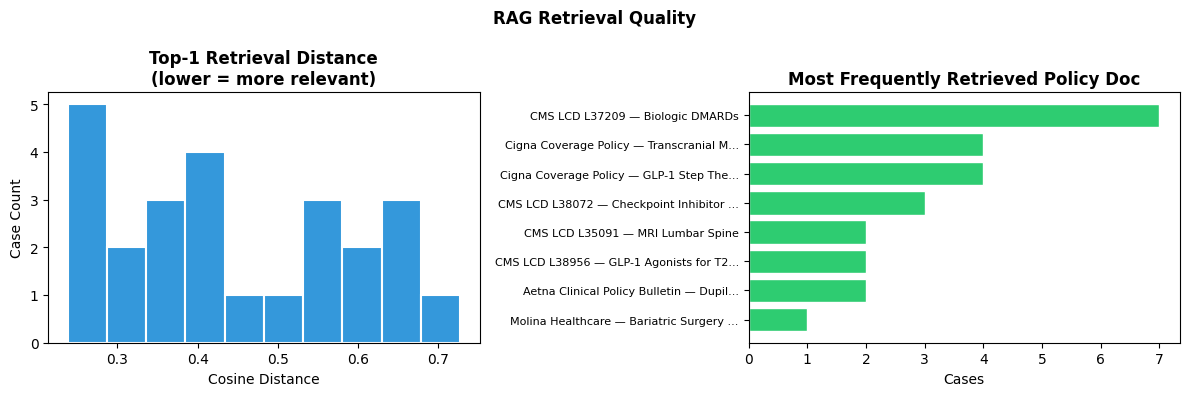

In [11]:
#RAG Retrieval Quality
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('RAG Retrieval Quality', fontweight='bold')

axes[0].hist(df_retrieval.top_distance.dropna(), bins=10,
             color='#3498db', edgecolor='white', linewidth=1.5)
axes[0].set_title('Top-1 Retrieval Distance\n(lower = more relevant)', fontweight='bold')
axes[0].set_xlabel('Cosine Distance')
axes[0].set_ylabel('Case Count')

source_counts  = df_retrieval.top_source.value_counts()
source_labels  = [s[:38] + '...' if len(s) > 38 else s for s in source_counts.index]
axes[1].barh(range(len(source_counts)), source_counts.values,
             color='#2ecc71', edgecolor='white', linewidth=1)
axes[1].set_yticks(range(len(source_counts)))
axes[1].set_yticklabels(source_labels, fontsize=8)
axes[1].set_title('Most Frequently Retrieved Policy Doc', fontweight='bold')
axes[1].set_xlabel('Cases')
axes[1].invert_yaxis()

plt.tight_layout()
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/03_retrieval_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## Export for Notebook 04

In [12]:
export = [{
    'case_id':               c['case_id'],
    'true_label':            c['true_label'],
    'insurance_type':        c['insurance_type'],
    'clinical_category':     c['clinical_category'],
    'documentation_quality': c['documentation_quality'],
    'note':                  c['note'],
    'predicted_extraction':  c['predicted_extraction'],
    'policy_context':        c['policy_context'],
    'retrieved_sources':     [ch['source'] for ch in c['retrieved_policy_chunks']],
} for c in enriched_cases]

with open('../data/enriched_cases.json', 'w') as f:
    json.dump(export, f, indent=2)

print(f'Saved {len(export)} enriched cases to data/enriched_cases.json')
print()
sample = export[0]
print(f'Sample policy context for {sample["case_id"]}:')
print('-' * 60)
print(sample['policy_context'][:500])
print('[... truncated ...]')

Saved 25 enriched cases to data/enriched_cases.json

Sample policy context for PA-001:
------------------------------------------------------------
[Source: Aetna Clinical Policy Bulletin — Dupilumab (Dupixent)]
AETNA COVERAGE CRITERIA — DUPILUMAB Atopic Dermatitis: Dupilumab is covered when ALL of the following are met: Confirmed diagnosis of moderate-to-severe atopic dermatitis by a dermatologist. EASI score >= 16 OR IGA score >= 3 OR BSA >= 10%. Inadequate response or intolerance to at least two topical therapies: medium-to-high potency topical corticosteroid and topical calcineurin inhibitor. Dermatology specialist evaluation and recomm
[... truncated ...]


## Production Extension

In [13]:
# ── Real PDF ingestion — uncomment when policy PDFs are in data/payer_policies/ ──
# See data/payer_policies/README.md for which documents to download

# import PyPDF2
#
# def load_pdfs_from_folder(folder: str) -> List[dict]:
#     docs = []
#     for pdf_path in Path(folder).glob('*.pdf'):
#         with open(pdf_path, 'rb') as f:
#             reader = PyPDF2.PdfReader(f)
#             text = ' '.join(
#                 page.extract_text() for page in reader.pages if page.extract_text()
#             )
#         docs.append({
#             'doc_id': pdf_path.stem, 'source': pdf_path.name,
#             'category': 'general', 'text': text
#         })
#         print(f'Loaded: {pdf_path.name}  ({len(text.split())} words)')
#     return docs
#
# real_docs   = load_pdfs_from_folder('data/payer_policies/')
# real_chunks = []
# for doc in real_docs:
#     real_chunks.extend(chunk_document(doc, chunk_size=150, overlap=30))
# real_embeddings = embed_model.encode([c['text'] for c in real_chunks], show_progress_bar=True)
# collection.add(
#     ids=[c['chunk_id'] for c in real_chunks],
#     documents=[c['text'] for c in real_chunks],
#     embeddings=real_embeddings.tolist(),
#     metadatas=[{'doc_id': c['doc_id'], 'source': c['source']} for c in real_chunks]
# )
# print(f'Added {len(real_chunks)} real policy chunks to vector store')

print('PDF ingestion ready — uncomment when policy PDFs are available.')

PDF ingestion ready — uncomment when policy PDFs are available.


## Key Takeaways

- **RAG is the differentiator** — it anchors LLM output to specific payer criteria rather than generic rationale.

- **Chunking with overlap** preserves context across section boundaries in policy documents.

- **Query construction** — combining clinical category, ICD codes, and note text produces better retrieval than notes alone.

- **Production path** — replace synthetic policy text with real CMS LCDs via the PDF loader above.

**Next:** `04_prompt_engineering.ipynb`